In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from imblearn.datasets import fetch_datasets
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split, TunedThresholdClassifierCV

In [2]:
import warnings
warnings.filterwarnings("ignore", message="lbfgs failed to converge after")

## Load dataset

In [3]:
# Load dataset from imbalanced-learn.
def load_dataset(dataset):
    
    data = fetch_datasets()[dataset]
    data.target = np.where(data.target < 0, 0, 1)
    X, y = data.data, data.target
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=0)
    
    return X_train, X_test, y_train, y_test

In [4]:
X_train, X_test, y_train, y_test = load_dataset("protein_homo")

print(f"Target mean: {np.mean(y_train):.4f}")

Target mean: 0.0087


## Select best model

The aim is to select the best among various machine learning models trained to predict protein homology.

We train the models and then evaluate them using the balanced accuracy at it's optimal threshold, adjusted using the test set.

### Train models

In [5]:
# Machine learning models to train:

models = {
    "Logistic Regression": LogisticRegression(max_iter=10000, random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "GBM":                 GradientBoostingClassifier(random_state=42),
}

# Train the models
for name, model in models.items():
    model.fit(X_train, y_train)

### Evaluate with TunedThresholdClassifierCV

In [6]:
# Evaluate models optimising for balanced accuracy:

tuned_models = {
    name: TunedThresholdClassifierCV(
        estimator=model,
        scoring="balanced_accuracy",
        store_cv_results=True,
        cv="prefit", # important because we already trained the model
        refit=False, 
    )
    for name, model in models.items()
}

# Evaluate
results = {}
for name, tuned_model in tuned_models.items():
    
    # Important: it's not fitting, just finding the best threshold:
    # because we used prefit in cv:
    tuned_model.fit(X_test, y_test)

    # Now, predict() uses the optimal threshold,
    # no longer the default 0.5:
    ba = balanced_accuracy_score(y_test, tuned_model.predict(X_test))

    # Print results
    results[name] = {
        "balanced_accuracy": ba,
        "threshold": tuned_model.best_threshold_,
    }
    print(f"{name:25s} | Balanced Accuracy: {ba:.4f} | Threshold: {tuned_model.best_threshold_:.4f}")

Logistic Regression       | Balanced Accuracy: 0.9467 | Threshold: 0.0101
Random Forest             | Balanced Accuracy: 0.9562 | Threshold: 0.0202
GBM                       | Balanced Accuracy: 0.9387 | Threshold: 0.0101


In [7]:
# sklearn tests 100 different thresholds

tuned_models["GBM"].thresholds

100

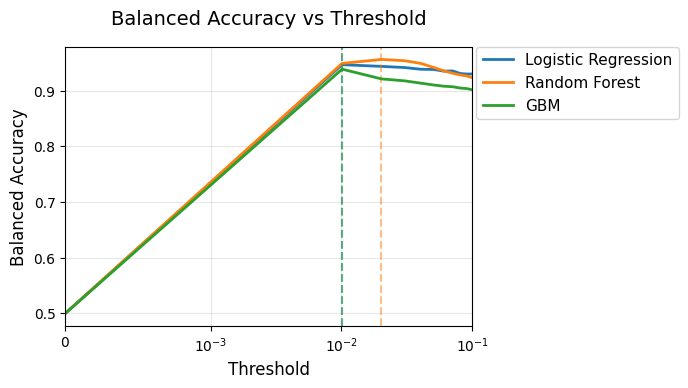

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))

for name, tuned_model in tuned_models.items():
    thresholds = tuned_model.cv_results_["thresholds"]
    scores     = tuned_model.cv_results_["scores"]
    line,      = ax.plot(thresholds, scores, label=name, linewidth=2)
    ax.axvline(x=tuned_model.best_threshold_, linestyle='--', alpha=0.5, color=line.get_color())

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Balanced Accuracy", fontsize=12)
ax.set_title("Balanced Accuracy vs Threshold", fontsize=14, y=1.05)
ax.legend(fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.set_xscale("symlog", linthresh=0.001)
ax.set_xlim(0, 0.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TunedThresholdClassifierCV does not have enough granularity over the threshold cut-off points.

### Evaluate manually

In [9]:
curve_data = {}

for name, model in models.items():

    # scores
    probs = model.predict_proba(X_test)[:, 1]

    # all thresholds
    thresholds = np.unique(probs)

    # balanced accuracy
    bas = [balanced_accuracy_score(y_test, probs >= t) for t in thresholds]
    
    curve_data[name] = {
        "thresholds": thresholds,
        "metrics": bas,
        "best_thresh": thresholds[np.argmax(bas)],
    }

In [10]:
for name, data in curve_data.items():
    print(f"{name:25s} | Balanced Accuracy: {np.max(data["metrics"]):.4f} | Threshold: {data["best_thresh"]:.4f}")

Logistic Regression       | Balanced Accuracy: 0.9553 | Threshold: 0.0052
Random Forest             | Balanced Accuracy: 0.9562 | Threshold: 0.0300
GBM                       | Balanced Accuracy: 0.9537 | Threshold: 0.0056


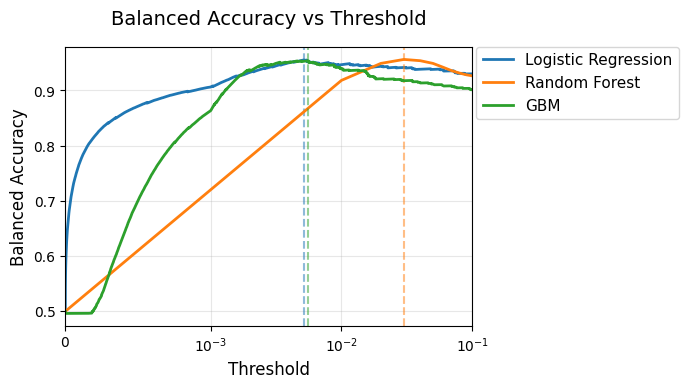

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))

for name, data in curve_data.items():
    line, = ax.plot(data["thresholds"], data["metrics"], label=name, linewidth=2)
    ax.axvline(x=data["best_thresh"], linestyle='--', alpha=0.5, color=line.get_color())

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Balanced Accuracy", fontsize=12)
ax.set_title("Balanced Accuracy vs Threshold", fontsize=14, y=1.05)
ax.legend(fontsize=11, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
ax.set_xscale("symlog", linthresh=0.001)
ax.set_xlim(0, 0.1)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch2/ch2-fig6.png', dpi=300, bbox_inches='tight')
plt.show()

## Performance dispersion

In [12]:
def optimal_ba(y, prob):
    thresholds = np.unique(prob)
    ba_ls = [balanced_accuracy_score(y, prob >= t) for t in thresholds]
    best_idx = np.argmax(ba_ls)
    return max(ba_ls), thresholds[best_idx]

In [13]:
def evaluate_model_on_test_set(model, X, y):
    # To obtain a dispersion value, we take
    # bootstrap samples of the test set.
    X = np.asarray(X)
    y = np.asarray(y)
    n = int(0.6 * len(X))

    ba, thresh = [], []

    for seed in range(1, 6):
        idx = np.random.default_rng(seed).choice(len(X), size=n, replace=True)
        xs, ys = X[idx], y[idx]
        prob = model.predict_proba(xs)[:, 1]

        ba_val, thresh_val = optimal_ba(ys, prob)
        ba.append(ba_val)
        thresh.append(thresh_val)

    return np.mean(ba), np.std(ba), np.mean(thresh), np.std(thresh)

In [14]:
results = {}

for name, model in models.items():

    results[name] = evaluate_model_on_test_set(model, X_test, y_test)

In [15]:
df = pd.DataFrame(results, index=["ba_mean", "ba_std", "thresh_mean", "thresh_std"]).T

print(df)

                      ba_mean    ba_std  thresh_mean  thresh_std
Logistic Regression  0.957726  0.004853     0.008042    0.004325
Random Forest        0.961222  0.006537     0.036000    0.008000
GBM                  0.963208  0.002442     0.006003    0.001570


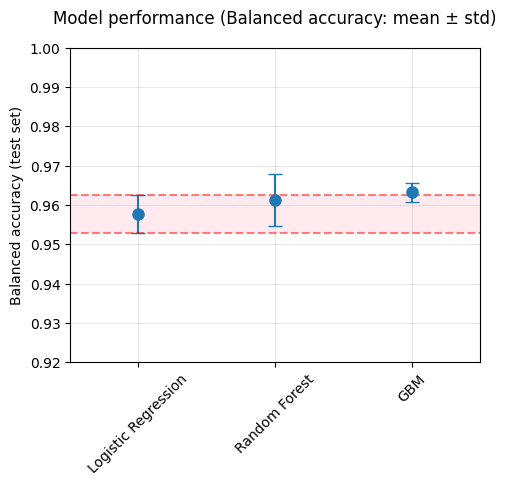

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))

cls   = df.index
means = df.iloc[:, 0]
stds  = df.iloc[:, 1]

upper = df.iloc[0, 0] + df.iloc[0, 1]
lower = df.iloc[0, 0] - df.iloc[0, 1]

ax.errorbar(x=cls, y=means, yerr=stds,
            fmt='o', capsize=5, markersize=8)

ax.set_title('Model performance (Balanced accuracy: mean ± std)', fontsize=12, y=1.05)
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.5, len(cls) - 0.5)
ax.set_ylabel('Balanced accuracy (test set)', fontsize=10)
ax.set_ylim(0.92, 1)

ax.axhline(y=upper, color='r', linestyle='--', alpha=0.5)
ax.axhline(y=lower, color='r', linestyle='--', alpha=0.5)
ax.axhspan(ymin=lower, ymax=upper, facecolor='pink', alpha=0.3)

plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch2/ch2-fig7.png', dpi=300, bbox_inches='tight')
plt.show()

## Hyperparameter optimisation

In [17]:
from sklearn.metrics import make_scorer

# balanced accuracy at optimal threshold
def balanced_accuracy(y, prob):
    thresholds = np.unique(prob)
    ba_ls = [balanced_accuracy_score(y, prob >= t) for t in thresholds]
    return max(ba_ls)

# function to maximise
ba_score = make_scorer(
    balanced_accuracy, 
    response_method='predict_proba', 
    greater_is_better=True,
)

In [18]:
from sklearn.model_selection import GridSearchCV

gbm = models["GBM"]

search = GridSearchCV(
    estimator=gbm,
    param_grid={
        "n_estimators":   [50, 100, 200],
        "max_depth":      [2, 3, 5],
        "learning_rate":  [0.01, 0.05, 0.1],
    },
    scoring=ba_score,
    cv=3,
    refit=True,
)

# this takes a while
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(b...redict_proba')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter 

In [19]:
search.best_estimator_

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [20]:
search.best_score_

np.float64(0.9484007523044339)

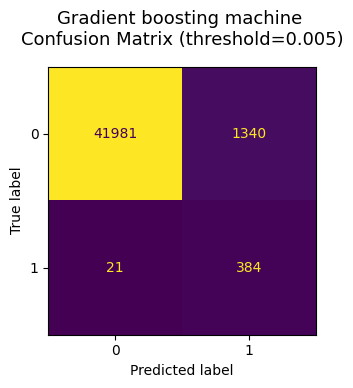

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

y_pred = search.predict_proba(X_test)[:, 1]
_, thresh = optimal_ba(y_test, y_pred)

cm = confusion_matrix(y_test, y_pred>=thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=search.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Gradient boosting machine \nConfusion Matrix (threshold={thresh:.3f})", fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch2/ch2-fig8.png', dpi=300, bbox_inches='tight')
plt.show()